In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

In [3]:
data = pd.read_csv("heart.csv")

In [4]:
X = data.drop("target", axis=1)
y = data["target"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [7]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [8]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [9]:
lr_acc = accuracy_score(y_test, lr_pred)
dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print("Logistic Regression:", lr_acc)
print("Decision Tree:", dt_acc)
print("Random Forest:", rf_acc)

Logistic Regression: 0.7951219512195122
Decision Tree: 0.9853658536585366
Random Forest: 0.9853658536585366


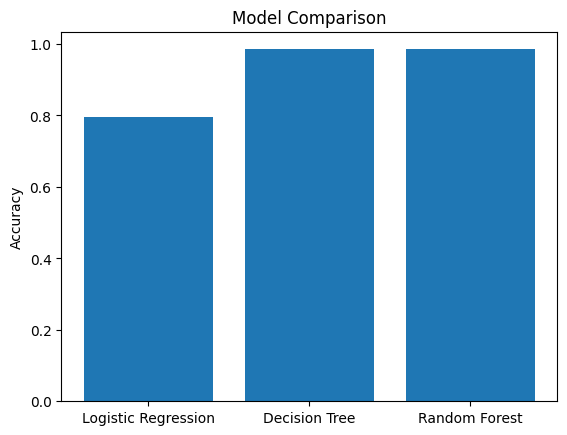

In [10]:
models = ["Logistic Regression", "Decision Tree", "Random Forest"]
scores = [lr_acc, dt_acc, rf_acc]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [11]:
print("Decision Tree Train Accuracy:", dt.score(X_train, y_train))
print("Decision Tree Test Accuracy:", dt.score(X_test, y_test))

print("Random Forest Train Accuracy:", rf.score(X_train, y_train))
print("Random Forest Test Accuracy:", rf.score(X_test, y_test))

Decision Tree Train Accuracy: 1.0
Decision Tree Test Accuracy: 0.9853658536585366
Random Forest Train Accuracy: 1.0
Random Forest Test Accuracy: 0.9853658536585366


Key Insights:


- Both Random Forest and Decision Tree achieved very high accuracy (~0.98).
- Logistic Regression showed lower performance (~0.79), suggesting that linear relationships may not fully capture the patterns in the data.
- Tree-based models are better at capturing complex, non-linear relationships between clinical variables.

Critical Reflection:

- The extremely high accuracy (0.98) for both Decision Tree and Random Forest may indicate potential overfitting, especially for the Decision Tree model.
- Decision Trees can memorise training data and may not generalise well to new, unseen data.
- Random Forest reduces overfitting by combining multiple trees, but performance should still be validated carefully.

Governance Perspective:

- While tree-based models achieved higher accuracy, their complexity may reduce interpretability in clinical settings.
- Logistic Regression, despite lower accuracy, offers greater transparency and explainability, which is important for clinical decision-making.
- In healthcare, model selection should balance:
  - predictive performance
  - interpretability
  - clinical trust
  - regulatory requirements

Practical Implication:

- A slightly less accurate but more interpretable model may sometimes be preferred in healthcare applications.
- Additional evaluation metrics (e.g., precision, recall) and external validation are necessary before deploying any model in real-world clinical settings.